# Assignment 2: Identifying Rice Areas

**Integrantes**

- Max Chipani
- Julio Molina
- Irina Valenzuela

**Fase actual:** Fase 1 — preparación reproducible, Earth Engine, Bellavista,
AlphaEarth 2019, máscara cropland y muestra de embeddings.

## 2. Consigna y objetivo

El objetivo general es identificar áreas de arroz en Bellavista (San Martín)
mediante clustering no supervisado de embeddings AlphaEarth y validación
posterior con GloRice-I. Esta primera fase se limita a construir y validar una
muestra reproducible de píxeles agrícolas.

En esta fase no se ejecutan Clustergram, selección de `k`, K-Means final,
GloRice-I ni el análisis de incendios.

## 3. Entorno y reproducibilidad

El notebook está diseñado para ejecutarse desde la raíz del repositorio con el
entorno Conda `geoagent2`. No contiene instalaciones, credenciales, tokens ni
rutas absolutas.

In [1]:
from __future__ import annotations

from datetime import datetime, timezone
from importlib import metadata
from pathlib import Path
import hashlib
import json
import math
import platform
import time

import ee
import geemap
import geopandas as gpd
import matplotlib.pyplot as plt
import netCDF4
import numpy as np
import pandas as pd
import pyarrow
import rasterio
import sklearn
import xarray as xr

# Cada usuario puede sustituir este valor por su propio proyecto habilitado
# para Google Earth Engine.
EE_PROJECT = "geoagent-assignment-2"

REPO_ROOT = Path.cwd()
ASSIGNMENT_DIR = REPO_ROOT / "Assignments" / "Assignment2"
OUTPUT_DIR = ASSIGNMENT_DIR / "outputs_grupo3"
CACHE_DIR = ASSIGNMENT_DIR / "cache_grupo3"
GEE_CACHE_DIR = CACHE_DIR / "raw" / "gee"
MANIFEST_DIR = CACHE_DIR / "manifests"
TMP_DIR = CACHE_DIR / "tmp"

for directory in (OUTPUT_DIR, GEE_CACHE_DIR, MANIFEST_DIR, TMP_DIR):
    directory.mkdir(parents=True, exist_ok=True)

CSV_PATH = GEE_CACHE_DIR / "alphaearth_bellavista_cropland_sample_2019.csv"
PARQUET_PATH = GEE_CACHE_DIR / "alphaearth_bellavista_cropland_sample_2019.parquet"
MANIFEST_PATH = MANIFEST_DIR / "phase1_manifest.json"

BANDS = [f"A{i:02d}" for i in range(64)]
SAMPLE_SIZE = 10_000
SAMPLE_SCALE_M = 10
SAMPLE_SEED = 42
TILE_SCALE = 8
PHASE1_STARTED = time.perf_counter()
EXECUTED_AT_UTC = datetime.now(timezone.utc)

package_names = [
    "earthengine-api", "geemap", "clustergram", "netCDF4",
    "scikit-learn", "xarray", "rasterio", "geopandas",
    "pandas", "numpy", "matplotlib", "pyarrow",
]
environment_versions = {
    name: metadata.version(name) for name in package_names
}
environment_versions["python"] = platform.python_version()

pd.DataFrame(
    {"package": list(environment_versions), "version": list(environment_versions.values())}
)

,package,version
0,earthengine-api,1.7.36
1,geemap,0.38.3
2,clustergram,0.8.1
3,netCDF4,1.7.4
4,scikit-learn,1.9.0
5,xarray,2026.7.0
6,rasterio,1.5.0
7,geopandas,1.1.4
8,pandas,3.0.3
9,numpy,2.5.1


## 4. Fuentes de datos

- Región: `FAO/GAUL/2015/level2`.
- Embeddings: `GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL`.
- Máscara agrícola: imagen `ESA/WorldCover/v200/2021`, banda `Map`, clase 40.

Los 64 valores `A00`–`A63` son las únicas variables que entrarán al clustering.
La máscara, coordenadas, geometrías e identificadores no forman parte de `X`.

## 5. Limitaciones temporales

AlphaEarth resume las condiciones de **2019**, mientras que WorldCover v200
representa **2021**. WorldCover se usa exclusivamente como máscara espacial de
cropland; no se interpreta como referencia de arroz ni como evidencia temporal
de cultivo en 2019.

## 6. Inicialización de Earth Engine

In [2]:
ee.Initialize(project=EE_PROJECT)
ee_probe = ee.Number(1).getInfo()
assert ee_probe == 1
print(f"Earth Engine inicializado correctamente con el proyecto: {EE_PROJECT}")

Earth Engine inicializado correctamente con el proyecto: geoagent-assignment-2


## 7. Región de Bellavista

In [3]:
gaul2 = ee.FeatureCollection("FAO/GAUL/2015/level2")
selected = (
    gaul2
    .filter(ee.Filter.eq("ADM1_NAME", "San Martín"))
    .filter(ee.Filter.eq("ADM2_NAME", "Bellavista"))
)

region_count = int(selected.size().getInfo())
if region_count != 1:
    raise RuntimeError(
        f"Bellavista debe devolver exactamente una entidad; se obtuvieron {region_count}."
    )

geometry = selected.geometry()
region_area_km2 = float(geometry.area(maxError=1).divide(1e6).getInfo())
if not math.isfinite(region_area_km2) or region_area_km2 <= 0:
    raise RuntimeError("La geometría de Bellavista está vacía o tiene área inválida.")

region_properties = (
    selected.first()
    .toDictionary(["ADM0_NAME", "ADM1_NAME", "ADM2_NAME"])
    .getInfo()
)
region_bounds = geometry.bounds(maxError=1).coordinates().getInfo()

REGION_SUMMARY = {
    "feature_count": region_count,
    "territorial_name": region_properties,
    "area_km2": region_area_km2,
    "bounds": region_bounds,
}
print(json.dumps(REGION_SUMMARY, ensure_ascii=False, indent=2))

{
  "feature_count": 1,
  "territorial_name": {
    "ADM0_NAME": "Peru",
    "ADM1_NAME": "San Martín",
    "ADM2_NAME": "Bellavista"
  },
  "area_km2": 7823.890636174687,
  "bounds": [
    [
      [
        -76.72772059259887,
        -8.382597192415476
      ],
      [
        -75.83685914684455,
        -8.382597192415476
      ],
      [
        -75.83685914684455,
        -6.725604127574741
      ],
      [
        -76.72772059259887,
        -6.725604127574741
      ],
      [
        -76.72772059259887,
        -8.382597192415476
      ]
    ]
  ]
}


## 8. AlphaEarth 2019

In [4]:
ALPHAEARTH_DATASET = "GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL"
START_DATE = "2019-01-01"
END_DATE = "2020-01-01"

embedding_collection = (
    ee.ImageCollection(ALPHAEARTH_DATASET)
    .filterDate(START_DATE, END_DATE)
    .filterBounds(geometry)
)
embedding_image_count = int(embedding_collection.size().getInfo())
if embedding_image_count == 0:
    raise RuntimeError("La colección AlphaEarth 2019 está vacía en Bellavista.")

alphaearth_utm_zones = embedding_collection.aggregate_array("UTM_ZONE").distinct().getInfo()
if alphaearth_utm_zones != ["18S"]:
    raise RuntimeError(
        "Los tiles AlphaEarth que cubren Bellavista no comparten la zona UTM "
        f"esperada 18S: {alphaearth_utm_zones}"
    )

reference_image = ee.Image(embedding_collection.first()).select(BANDS)
reference_projection = reference_image.select("A00").projection()
embeddingsImage = (
    embedding_collection
    .mosaic()
    .select(BANDS)
    .setDefaultProjection(reference_projection)
    .clip(geometry)
)
observed_bands = embeddingsImage.bandNames().getInfo()
if observed_bands != BANDS:
    raise RuntimeError(
        "Las bandas AlphaEarth no coinciden exactamente con A00–A63 en el orden esperado."
    )

reference_crs = reference_projection.crs().getInfo()
nominal_scale_m = float(reference_projection.nominalScale().getInfo())
if reference_crs != "EPSG:32718" or not math.isclose(
    nominal_scale_m, 10.0, rel_tol=0, abs_tol=1e-9
):
    raise RuntimeError(
        f"Proyección AlphaEarth inesperada: {reference_crs}, {nominal_scale_m} m."
    )

valid_embedding_area_m2 = float(
    ee.Image.pixelArea()
    .updateMask(embeddingsImage.select("A00").mask())
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=geometry,
        scale=SAMPLE_SCALE_M,
        maxPixels=1e11,
        tileScale=TILE_SCALE,
    )
    .get("area")
    .getInfo()
)
embedding_coverage_pct = 100 * valid_embedding_area_m2 / (region_area_km2 * 1e6)

ALPHAEARTH_SUMMARY = {
    "dataset": ALPHAEARTH_DATASET,
    "period": [START_DATE, END_DATE],
    "image_count": embedding_image_count,
    "band_count": len(observed_bands),
    "bands": observed_bands,
    "nominal_scale_m": nominal_scale_m,
    "reference_crs": reference_crs,
    "utm_zones": alphaearth_utm_zones,
    "valid_coverage_pct_of_bellavista": embedding_coverage_pct,
    "additional_normalization": False,
}
print(json.dumps(ALPHAEARTH_SUMMARY, ensure_ascii=False, indent=2))

{
  "dataset": "GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL",
  "period": [
    "2019-01-01",
    "2020-01-01"
  ],
  "image_count": 4,
  "band_count": 64,
  "bands": [
    "A00",
    "A01",
    "A02",
    "A03",
    "A04",
    "A05",
    "A06",
    "A07",
    "A08",
    "A09",
    "A10",
    "A11",
    "A12",
    "A13",
    "A14",
    "A15",
    "A16",
    "A17",
    "A18",
    "A19",
    "A20",
    "A21",
    "A22",
    "A23",
    "A24",
    "A25",
    "A26",
    "A27",
    "A28",
    "A29",
    "A30",
    "A31",
    "A32",
    "A33",
    "A34",
    "A35",
    "A36",
    "A37",
    "A38",
    "A39",
    "A40",
    "A41",
    "A42",
    "A43",
    "A44",
    "A45",
    "A46",
    "A47",
    "A48",
    "A49",
    "A50",
    "A51",
    "A52",
    "A53",
    "A54",
    "A55",
    "A56",
    "A57",
    "A58",
    "A59",
    "A60",
    "A61",
    "A62",
    "A63"
  ],
  "nominal_scale_m": 10.0,
  "reference_crs": "EPSG:32718",
  "utm_zones": [
    "18S"
  ],
  "valid_coverage_pct_of_bellavista": 

## 9. WorldCover y máscara cropland

In [5]:
WORLDCOVER_DATASET = "ESA/WorldCover/v200/2021"
worldcover = ee.Image(WORLDCOVER_DATASET).select("Map").clip(geometry)
croplandMask = worldcover.eq(40).rename("cropmask")

cropland_area_m2 = float(
    ee.Image.pixelArea()
    .updateMask(croplandMask)
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=geometry,
        scale=SAMPLE_SCALE_M,
        maxPixels=1e11,
        tileScale=TILE_SCALE,
    )
    .get("area")
    .getInfo()
)
cropland_area_km2 = cropland_area_m2 / 1e6
cropland_pct = 100 * cropland_area_km2 / region_area_km2

CROPLAND_SUMMARY = {
    "dataset": WORLDCOVER_DATASET,
    "band": "Map",
    "class_value": 40,
    "class_name": "Cropland",
    "bellavista_area_km2": region_area_km2,
    "cropland_area_km2": cropland_area_km2,
    "cropland_pct_of_bellavista": cropland_pct,
    "temporal_mismatch": {
        "alphaearth_year": 2019,
        "worldcover_year": 2021,
    },
    "use": "spatial cropland mask only; not a rice reference",
}
print(json.dumps(CROPLAND_SUMMARY, ensure_ascii=False, indent=2))

{
  "dataset": "ESA/WorldCover/v200/2021",
  "band": "Map",
  "class_value": 40,
  "class_name": "Cropland",
  "bellavista_area_km2": 7823.890636174687,
  "cropland_area_km2": 186.78628729220992,
  "cropland_pct_of_bellavista": 2.3873836685367427,
  "temporal_mismatch": {
    "alphaearth_year": 2019,
    "worldcover_year": 2021
  },
  "use": "spatial cropland mask only; not a rice reference"
}


## 10. Muestreo de embeddings

La máscara contiene una única clase válida (`cropland`), por lo que
un muestreo dirigido de la única clase válida evita que el factor aproximado de
`ee.Image.sample` se calcule sobre los píxeles no agrícolas de toda Bellavista.
Por ello se usa `stratifiedSample` únicamente para obtener exactamente 10,000
píxeles de la clase 1. `cropmask` se elimina inmediatamente después del muestreo
y no forma parte de la matriz de variables. La geometría se conserva únicamente
para control espacial.

In [6]:
clusterImage = embeddingsImage.updateMask(croplandMask).select(BANDS)
sampling_image = clusterImage.addBands(croplandMask)

sample_with_mask_fc = sampling_image.stratifiedSample(
    numPoints=0,
    classBand="cropmask",
    region=geometry,
    scale=SAMPLE_SCALE_M,
    projection=reference_projection,
    seed=SAMPLE_SEED,
    classValues=[1],
    classPoints=[SAMPLE_SIZE],
    dropNulls=True,
    tileScale=TILE_SCALE,
    geometries=True,
)

sample_mask_histogram = sample_with_mask_fc.aggregate_histogram("cropmask").getInfo()
sample_cropland_count = int(sample_mask_histogram.get("1", 0))
if sample_cropland_count != SAMPLE_SIZE or len(sample_mask_histogram) != 1:
    raise RuntimeError(
        "La muestra dirigida no contiene exclusivamente 10,000 observaciones "
        f"cropmask == 1: {sample_mask_histogram}"
    )

# cropmask se usa únicamente para dirigir y validar el muestreo. Se elimina
# antes de la transferencia y nunca entra en la matriz X.
sample_fc = sample_with_mask_fc.select(BANDS)

sample_server_count = int(sample_fc.size().getInfo())
if sample_server_count != SAMPLE_SIZE:
    raise RuntimeError(
        f"Se solicitaron {SAMPLE_SIZE} muestras, pero Earth Engine generó "
        f"{sample_server_count}. No se reducirá el tamaño silenciosamente."
    )

download_method = "geemap.ee_to_gdf via ee.data.computeFeatures"
fallback_export = None

try:
    sample_gdf = geemap.ee_to_gdf(sample_fc)
except Exception as direct_error:
    def add_coordinates(feature):
        coordinates = feature.geometry().coordinates()
        return feature.set(
            {
                "sample_lon": coordinates.get(0),
                "sample_lat": coordinates.get(1),
            }
        )

    export_fc = sample_fc.map(add_coordinates)
    export_task = ee.batch.Export.table.toDrive(
        collection=export_fc,
        description="Assignment2_Phase1_AlphaEarth_Bellavista_2019",
        folder="GeoAgent_Assignment2",
        fileNamePrefix="alphaearth_bellavista_cropland_sample_2019",
        fileFormat="CSV",
        selectors=BANDS + ["sample_lon", "sample_lat"],
    )
    export_task.start()
    fallback_export = export_task.status()
    fallback_manifest = {
        "status": "DIRECT_TRANSFER_FAILED",
        "error_type": type(direct_error).__name__,
        "error": str(direct_error),
        "task": fallback_export,
        "requested_samples": SAMPLE_SIZE,
    }
    MANIFEST_PATH.write_text(
        json.dumps(fallback_manifest, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    raise RuntimeError(
        "La transferencia directa falló. Se creó una tarea controlada de "
        f"Export.table.toDrive con task ID {fallback_export.get('id')}. "
        "Complete la descarga y reanude la fase."
    ) from direct_error

missing_downloaded_bands = [band for band in BANDS if band not in sample_gdf.columns]
if missing_downloaded_bands:
    raise RuntimeError(
        f"La transferencia no contiene todas las bandas: {missing_downloaded_bands}"
    )
if sample_gdf.geometry.isna().any():
    raise RuntimeError("La muestra contiene geometrías nulas.")

sample_gdf = sample_gdf.to_crs("EPSG:4326")
sample_df = sample_gdf[BANDS].copy()
sample_df["sample_lon"] = sample_gdf.geometry.x.to_numpy()
sample_df["sample_lat"] = sample_gdf.geometry.y.to_numpy()
sample_df = sample_df.sort_values(
    ["sample_lat", "sample_lon"], kind="mergesort"
).reset_index(drop=True)

sample_df.to_csv(CSV_PATH, index=False, float_format="%.17g")
sample_df.to_parquet(PARQUET_PATH, index=False, engine="pyarrow")

print(f"Método de transferencia: {download_method}")
print(f"Muestras guardadas: {len(sample_df):,}")
print(f"CSV: {CSV_PATH.relative_to(REPO_ROOT)}")
print(f"Parquet: {PARQUET_PATH.relative_to(REPO_ROOT)}")

Método de transferencia: geemap.ee_to_gdf via ee.data.computeFeatures
Muestras guardadas: 10,000
CSV: Assignments\Assignment2\cache_grupo3\raw\gee\alphaearth_bellavista_cropland_sample_2019.csv
Parquet: Assignments\Assignment2\cache_grupo3\raw\gee\alphaearth_bellavista_cropland_sample_2019.parquet


## 11. Clustergram y selección de k

Pendiente para la Fase 2. Se evaluará `k = 1…11` con backend sklearn y las
64 bandas originales. **No ejecutado en esta fase.**

## 12. Clustering final

Pendiente. Solo se ejecutará después de aprobar `k`. **No ejecutado en esta
fase.**

## 13. GloRice-I

Pendiente. Se utilizarán `ex_phsc_2019.nc` e `in_phsc_2019.nc` después de la
aprobación correspondiente. **No se descargaron datos en esta fase.**

## 14. Clasificación rice/non-rice

Pendiente. La regla será `rice_proportion > 0.50`. **No ejecutado en esta fase.**

## 15. Incendios 2017–2019

Pendiente. Se utilizará VIIRS S-NPP Standard Processing. **No se descargaron ni
procesaron detecciones en esta fase.**

## 16. Normalización por área

Pendiente. Se reportarán conteos brutos, área fija por clase y detecciones por
100 km². **No ejecutado en esta fase.**

## 17. Resultados y discusión

Pendiente de las fases analíticas. No se anticipan resultados ni conclusiones.

## 18. Control de calidad

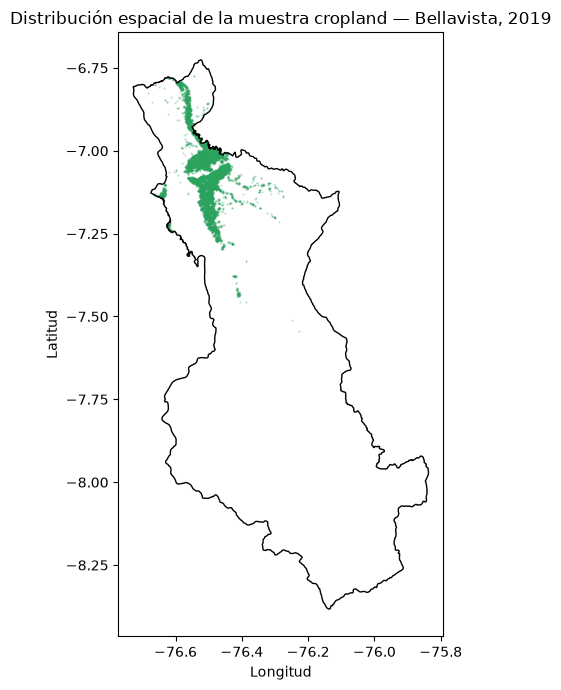

Validación de la muestra:
{
  "requested_rows": 10000,
  "actual_rows": 10000,
  "feature_columns": [
    "A00",
    "A01",
    "A02",
    "A03",
    "A04",
    "A05",
    "A06",
    "A07",
    "A08",
    "A09",
    "A10",
    "A11",
    "A12",
    "A13",
    "A14",
    "A15",
    "A16",
    "A17",
    "A18",
    "A19",
    "A20",
    "A21",
    "A22",
    "A23",
    "A24",
    "A25",
    "A26",
    "A27",
    "A28",
    "A29",
    "A30",
    "A31",
    "A32",
    "A33",
    "A34",
    "A35",
    "A36",
    "A37",
    "A38",
    "A39",
    "A40",
    "A41",
    "A42",
    "A43",
    "A44",
    "A45",
    "A46",
    "A47",
    "A48",
    "A49",
    "A50",
    "A51",
    "A52",
    "A53",
    "A54",
    "A55",
    "A56",
    "A57",
    "A58",
    "A59",
    "A60",
    "A61",
    "A62",
    "A63"
  ],
  "feature_column_count": 64,
  "exact_band_order": true,
  "null_values": 0,
  "all_finite": true,
  "cropmask_in_X": false,
  "coordinate_columns_in_X": false,
  "geometry_in_X": false,
  

sample_lon,0,1,2,3
sample_lat,,,,
0,0,0,72,2
1,73,1553,52,12
2,249,6177,511,46
3,357,896,0,0


Manifiesto: Assignments\Assignment2\cache_grupo3\manifests\phase1_manifest.json


In [7]:
X = sample_df[BANDS].copy()

validation = {
    "requested_rows": SAMPLE_SIZE,
    "actual_rows": int(len(sample_df)),
    "feature_columns": list(X.columns),
    "feature_column_count": int(X.shape[1]),
    "exact_band_order": list(X.columns) == BANDS,
    "null_values": int(X.isna().sum().sum()),
    "all_finite": bool(np.isfinite(X.to_numpy(dtype=np.float64)).all()),
    "cropmask_in_X": "cropmask" in X.columns,
    "coordinate_columns_in_X": bool(
        {"sample_lon", "sample_lat", "longitude", "latitude"} & set(X.columns)
    ),
    "geometry_in_X": "geometry" in X.columns,
    "identifier_columns_in_X": bool(
        {"id", "ID", "system:index", "index"} & set(X.columns)
    ),
    "exact_duplicate_embedding_rows": int(X.duplicated(keep=False).sum()),
}

if validation["actual_rows"] != SAMPLE_SIZE:
    raise RuntimeError("El número local de filas no coincide con el solicitado.")
if validation["feature_column_count"] != 64 or not validation["exact_band_order"]:
    raise RuntimeError("La matriz X no contiene exactamente A00–A63 en orden.")
if validation["null_values"] != 0 or not validation["all_finite"]:
    raise RuntimeError("La matriz X contiene valores nulos o no finitos.")
if any(
    validation[key]
    for key in (
        "cropmask_in_X",
        "coordinate_columns_in_X",
        "geometry_in_X",
        "identifier_columns_in_X",
    )
):
    raise RuntimeError("La matriz X contiene variables excluidas.")
if validation["exact_duplicate_embedding_rows"] != 0:
    raise RuntimeError(
        "Se detectaron filas de embeddings exactamente duplicadas; no se eliminaron."
    )

norms = np.linalg.norm(X.to_numpy(dtype=np.float64), axis=1)
norm_percentile_values = [0, 1, 5, 25, 50, 75, 95, 99, 100]
norm_percentiles = {
    str(percentile): float(np.percentile(norms, percentile))
    for percentile in norm_percentile_values
}
norm_summary = {
    "minimum": float(norms.min()),
    "maximum": float(norms.max()),
    "mean": float(norms.mean()),
    "standard_deviation": float(norms.std(ddof=0)),
    "percentiles": norm_percentiles,
    "renormalized": False,
}

non_cropland_sample_count = SAMPLE_SIZE - sample_cropland_count
if non_cropland_sample_count != 0:
    raise RuntimeError(
        f"{non_cropland_sample_count} puntos de muestra no están en WorldCover clase 40."
    )

boundary_gdf = geemap.ee_to_gdf(selected).to_crs("EPSG:4326")
sample_points_gdf = gpd.GeoDataFrame(
    sample_df[BANDS].copy(),
    geometry=gpd.points_from_xy(sample_df["sample_lon"], sample_df["sample_lat"]),
    crs="EPSG:4326",
)
region_geometry = boundary_gdf.geometry.union_all()
points_covered_by_region_exact = int(
    sample_points_gdf.geometry.covered_by(region_geometry).sum()
)
server_points_intersect_region_exact = int(
    sample_fc.filterBounds(geometry).size().getInfo()
)
server_points_intersect_region_5m = int(
    sample_fc.filterBounds(geometry.buffer(5)).size().getInfo()
)
if server_points_intersect_region_5m != SAMPLE_SIZE:
    raise RuntimeError(
        "Earth Engine reporta muestras a más de 5 m de la región de muestreo."
    )

# En el borde, la geometría del píxel de 10 m y la frontera vectorial pueden
# diferir por redondeo/reproyección. Se conserva el conteo exacto y se exige que
# todos los centros estén dentro de una tolerancia de medio píxel (5 m).
boundary_utm = boundary_gdf.to_crs(reference_crs)
sample_points_utm = sample_points_gdf.to_crs(reference_crs)
region_geometry_5m = boundary_utm.geometry.union_all().buffer(5)
points_covered_by_region_5m = int(
    sample_points_utm.geometry.covered_by(region_geometry_5m).sum()
)
if points_covered_by_region_5m != SAMPLE_SIZE:
    raise RuntimeError(
        "Existen muestras a más de 5 m de la geometría de Bellavista."
    )

lon_edges = np.linspace(sample_df["sample_lon"].min(), sample_df["sample_lon"].max(), 5)
lat_edges = np.linspace(sample_df["sample_lat"].min(), sample_df["sample_lat"].max(), 5)
lon_bin = pd.cut(
    sample_df["sample_lon"], bins=lon_edges, labels=False, include_lowest=True
)
lat_bin = pd.cut(
    sample_df["sample_lat"], bins=lat_edges, labels=False, include_lowest=True
)
spatial_grid_counts = (
    pd.crosstab(lat_bin, lon_bin)
    .reindex(index=range(4), columns=range(4), fill_value=0)
)

fig, ax = plt.subplots(figsize=(7, 7))
boundary_gdf.boundary.plot(ax=ax, color="black", linewidth=1.0)
ax.scatter(
    sample_df["sample_lon"],
    sample_df["sample_lat"],
    s=2,
    alpha=0.35,
    color="#2ca25f",
    linewidths=0,
)
ax.set_title("Distribución espacial de la muestra cropland — Bellavista, 2019")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file_handle:
        for chunk in iter(lambda: file_handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

files = {
    "csv": {
        "path": str(CSV_PATH.relative_to(REPO_ROOT)).replace("\\", "/"),
        "size_bytes": CSV_PATH.stat().st_size,
        "sha256": sha256_file(CSV_PATH),
    },
    "parquet": {
        "path": str(PARQUET_PATH.relative_to(REPO_ROOT)).replace("\\", "/"),
        "size_bytes": PARQUET_PATH.stat().st_size,
        "sha256": sha256_file(PARQUET_PATH),
    },
}

execution_time_seconds = time.perf_counter() - PHASE1_STARTED
memory = {
    "X_bytes": int(X.memory_usage(index=True, deep=True).sum()),
    "sample_dataframe_bytes": int(
        sample_df.memory_usage(index=True, deep=True).sum()
    ),
}

manifest = {
    "phase": "Assignment 2 - Phase 1",
    "executed_at_utc": EXECUTED_AT_UTC.isoformat(),
    "project_id": EE_PROJECT,
    "environment": environment_versions,
    "datasets": {
        "region": "FAO/GAUL/2015/level2",
        "alphaearth": ALPHAEARTH_DATASET,
        "worldcover": WORLDCOVER_DATASET,
    },
    "dates": {
        "alphaearth_start": START_DATE,
        "alphaearth_end_exclusive": END_DATE,
        "worldcover_year": 2021,
    },
    "region": REGION_SUMMARY,
    "alphaearth": ALPHAEARTH_SUMMARY,
    "cropland": CROPLAND_SUMMARY,
    "sampling": {
        "method": "ee.Image.stratifiedSample restricted to cropmask == 1",
        "download_method": download_method,
        "requested_samples": SAMPLE_SIZE,
        "server_samples": sample_server_count,
        "local_samples": len(sample_df),
        "scale_m": SAMPLE_SCALE_M,
        "seed": SAMPLE_SEED,
        "tile_scale": TILE_SCALE,
        "drop_nulls": True,
        "geometries_for_spatial_qc_only": True,
        "bands": BANDS,
        "stratified": True,
        "sample_mask_histogram": sample_mask_histogram,
    },
    "validation": {
        **validation,
        "non_cropland_sample_count": non_cropland_sample_count,
        "server_points_intersect_region_exact": server_points_intersect_region_exact,
        "server_points_intersect_region_5m": server_points_intersect_region_5m,
        "points_covered_by_region_exact": points_covered_by_region_exact,
        "points_covered_by_region_5m": points_covered_by_region_5m,
        "norms": norm_summary,
        "spatial_grid_counts_4x4": spatial_grid_counts.to_dict(),
    },
    "files": files,
    "memory": memory,
    "execution_time_seconds": execution_time_seconds,
}
MANIFEST_PATH.write_text(
    json.dumps(manifest, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("Validación de la muestra:")
print(json.dumps(validation, ensure_ascii=False, indent=2))
print("Resumen de normas:")
print(json.dumps(norm_summary, ensure_ascii=False, indent=2))
print("Conteos espaciales 4 × 4:")
display(spatial_grid_counts)
print(f"Manifiesto: {MANIFEST_PATH.relative_to(REPO_ROOT)}")

<!-- phase1-geometry-edge-validation -->
### Validación geométrica tolerante de borde

La auditoría de recuperación mantuvo el CRS original de las coordenadas
(`EPSG:4326`) y midió las distancias en la proyección de referencia de
AlphaEarth (`EPSG:32718`). De los 10,000 centros de píxel,
9,999 están dentro de la geometría exacta de Bellavista y
solo **1** (índice de muestra
`772`) aparece fuera por una
distancia submétrica:

- control local: máximo y percentiles 0, 25, 50, 75, 90, 95, 99 y 100 =
  `0.086381996228 m`;
- control autoritativo en Earth Engine: máximo y los mismos percentiles =
  `0.008638241444 m`;
- tolerancia aplicada: medio píxel de 10 m, es decir, **5.0 m**.

El punto coincide con un centro de la cuadrícula UTM de 10 m (residuo máximo
menor que 1 cm), su píxel intersecta Bellavista y Earth Engine confirmó que
pertenece a `WorldCover Map == 40`, posee las 64 bandas finitas y coincide
exactamente con el embedding guardado (diferencia máxima `0.0`). Por tanto,
se documenta como efecto normal de borde por reproyección/vectorización; el
punto se conserva y no se altera la región ni la muestra.

El detalle reproducible queda en
`Assignments/Assignment2/cache_grupo3/manifests/phase1_geometry_check.json`.


## 19. Inventario de entregables

In [8]:
inventory = pd.DataFrame(
    [
        {
            "artifact": "Notebook reproducible",
            "path": "Assignments/Assignment2/Assignment2_Identifying_Rice_Areas_grupo3.ipynb",
            "git_policy": "versionable",
        },
        {
            "artifact": "Muestra AlphaEarth CSV",
            "path": str(CSV_PATH.relative_to(REPO_ROOT)).replace("\\", "/"),
            "git_policy": "cache local; no versionar",
        },
        {
            "artifact": "Muestra AlphaEarth Parquet",
            "path": str(PARQUET_PATH.relative_to(REPO_ROOT)).replace("\\", "/"),
            "git_policy": "cache local; no versionar",
        },
        {
            "artifact": "Manifiesto Fase 1",
            "path": str(MANIFEST_PATH.relative_to(REPO_ROOT)).replace("\\", "/"),
            "git_policy": "cache local; no versionar",
        },
        {
            "artifact": "Outputs",
            "path": "Assignments/Assignment2/outputs_grupo3/",
            "git_policy": "vacío en Fase 1",
        },
    ]
)
inventory

,artifact,path,git_policy
0,Notebook reproducible,Assignments/Assignment2/Assignment2_Identifyin...,versionable
1,Muestra AlphaEarth CSV,Assignments/Assignment2/cache_grupo3/raw/gee/a...,cache local; no versionar
2,Muestra AlphaEarth Parquet,Assignments/Assignment2/cache_grupo3/raw/gee/a...,cache local; no versionar
3,Manifiesto Fase 1,Assignments/Assignment2/cache_grupo3/manifests...,cache local; no versionar
4,Outputs,Assignments/Assignment2/outputs_grupo3/,vacío en Fase 1
